# **HealthConnect Experience Lab — Week 5**
**Data Preparation, Feature Engineering & Baseline Model Development**

**AnalystLab Africa | Data Science Track | Shylet Nyazika**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving HealthConnect_Appointment_Data.csv to HealthConnect_Appointment_Data.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv("HealthConnect_Appointment_Data.csv")
print("Shape:", df.shape)

Shape: (5000, 18)


# Part 1: Review of Week 4 Foundation

**Review of Week 4 Foundation**

**Problem defined:** Predict whether a patient will miss (no-show) a scheduled appointment, using information available before the appointment occurs.

**Week 4 proposed approach:** Binary classification (no_show_target: No-Show=1, Attended=0), excluding Cancelled appointments (5.3% of data) since a cancellation is a communicated decision rather than an unexplained absence.

**Resources used:** HealthConnect_Appointment_Data.csv, HealthConnect_Data_Dictionary.xlsx.

**Key assumptions/limitations carried from Week 4:**

reminder_channel's missingness is structural (matches reminder_sent = 'No'), not random.
waiting_time_minutes was flagged as a possible data-leakage risk (might only be known after the appointment).
patient_id repeats across multiple appointments — random splitting risks patient-level leakage.

**Week 5 goal:** Move from planning into actual data preparation, feature engineering, a train/test strategy, and a baseline model.

# Part 2a: Data Preparation

In [3]:
print("waiting_time_minutes missing, by outcome:")
print(df.groupby('appointment_outcome')['waiting_time_minutes'].apply(lambda x: x.isna().sum()))
print()
print("Total appointments per outcome:")
print(df['appointment_outcome'].value_counts())

waiting_time_minutes missing, by outcome:
appointment_outcome
Attended     21
Cancelled     2
No-Show      37
Name: waiting_time_minutes, dtype: int64

Total appointments per outcome:
appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64


**Leakage Risk Resolved — Documented Change from Week 4**

waiting_time_minutes has a recorded value for the vast majority of No-Show and Cancelled appointments — not just Attended ones. If this were a true post-visit measurement, it should be missing entirely for patients who never showed up. Since it is populated regardless of outcome, it is evidently a pre-appointment estimate, not leakage. This resolves the Week 4 leakage concern: waiting_time_minutes can be safely used as a feature. This is a documented, evidence-based change from the Week 4 assumption, not a silent one.

In [4]:
# Exclude cancellations, define the target
model_df = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
model_df['no_show_target'] = (model_df['appointment_outcome'] == 'No-Show').astype(int)
print("Modelling rows:", len(model_df))
print("No-show rate:", round(model_df['no_show_target'].mean(), 4))

Modelling rows: 4737
No-show rate: 0.5115


In [5]:
# Handle missing values
model_df['reminder_channel'] = model_df['reminder_channel'].fillna('No Reminder')
model_df['distance_to_clinic_km'] = model_df['distance_to_clinic_km'].fillna(model_df['distance_to_clinic_km'].median())
model_df['waiting_time_minutes'] = model_df['waiting_time_minutes'].fillna(model_df['waiting_time_minutes'].median())

print("Remaining missing values:", model_df.isna().sum().sum())

Remaining missing values: 0


**Missing Value Treatment**

* **reminder_channel:** filled with "No Reminder" rather than a statistical imputation — this correctly represents the structural pattern identified in Week 4.
* **distance_to_clinic_km and waiting_time_minutes:** filled with the column median, since their missingness appears incidental rather than structural, and both are right-skewed numeric measurements where the median is a safer central estimate than the mean.

**Duplicates, Data Types, and Irrelevant Variables**

Duplicates and data type validity were already confirmed clean in Week 4 (0 duplicate rows, all columns correctly typed). appointment_id and patient_id are excluded as model features — they are identifiers, not predictive attributes. age_group is also excluded, since it is derived directly from age and would be redundant.

# Part 2b: Data Exploration & Visual Evidence

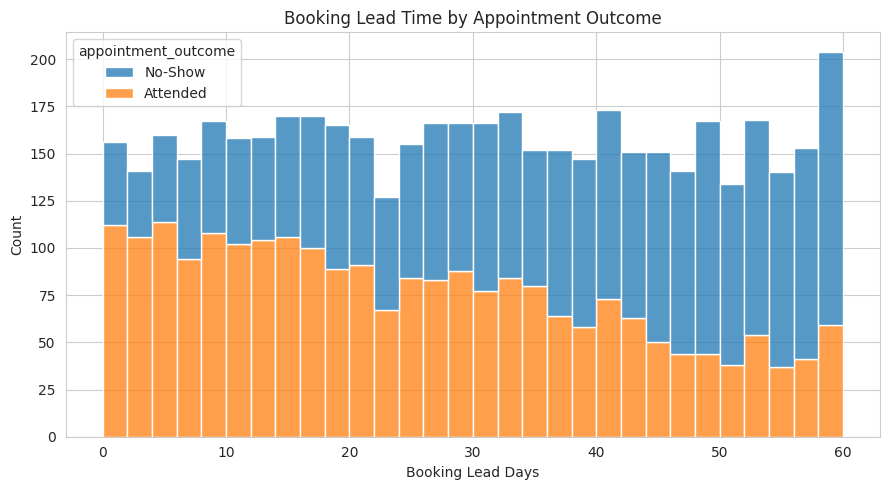

In [6]:
plt.figure(figsize=(9,5))
sns.histplot(data=model_df, x='booking_lead_days', hue='appointment_outcome', bins=30, multiple='stack')
plt.title("Booking Lead Time by Appointment Outcome")
plt.xlabel("Booking Lead Days")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Booking Lead Time — Interpretation**

No-shows become clearly more common, both in raw count and proportion, as booking lead time increases. In the first few days (0-5 days), the split between Attended and No-Show is fairly close (roughly even, with Attended sometimes slightly ahead). By the time lead time reaches 40-60 days, No-Show clearly dominates, with the gap widening sharply in the final bins — at 58-60 days, No-Show counts (over 200) are more than triple the Attended counts (around 60). This confirms a strong, consistent pattern: the further in advance an appointment is booked, the less likely a patient is to actually attend. This directly informed feature engineering: a binned high_lead_time feature was created (see Part 3), and booking_lead_days was kept as a raw numeric feature rather than dropped, since the relationship is clear and worth capturing in both forms.

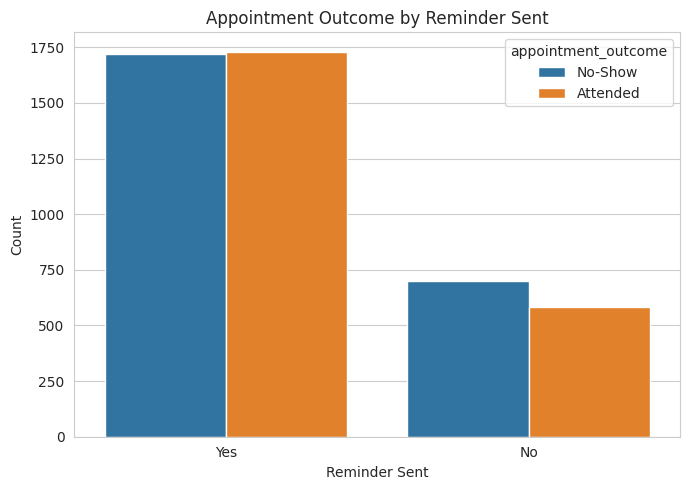

reminder_sent
No     0.5463
Yes    0.4986
Name: no_show_target, dtype: float64


In [7]:
plt.figure(figsize=(7,5))
sns.countplot(data=model_df, x='reminder_sent', hue='appointment_outcome')
plt.title("Appointment Outcome by Reminder Sent")
plt.xlabel("Reminder Sent")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(model_df.groupby('reminder_sent')['no_show_target'].mean().round(4))

**Reminders — Interpretation**

When a reminder was sent, the no-show rate is 49.9% (essentially a coin flip between attending and not); when no reminder was sent, the no-show rate rises to 54.6%. This is a real but modest effect — about a 4.8 percentage point difference — noticeably smaller than the booking lead time pattern observed above. Reminders appear to help somewhat, but they are far from a dominant factor on their own. This informed a modelling decision: reminder_sent and reminder_channel are retained as features, but this smaller effect size sets a realistic expectation that historical behaviour and booking patterns are likely to carry more predictive weight than reminder engagement alone.

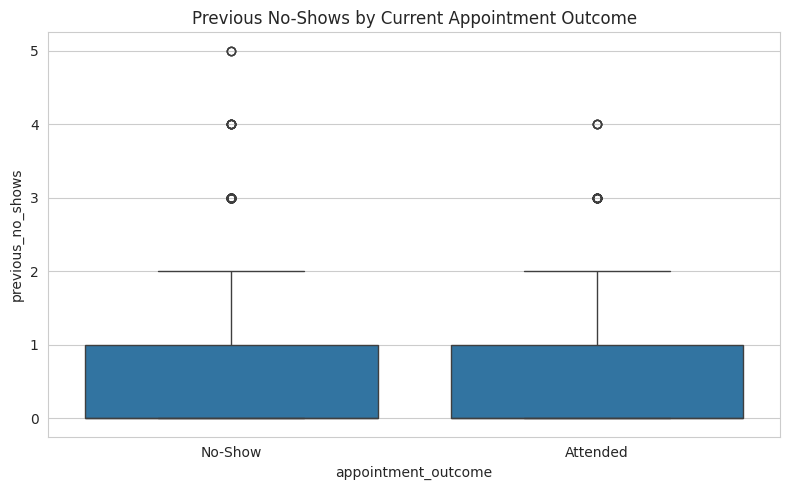

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=model_df, x='appointment_outcome', y='previous_no_shows')
plt.title("Previous No-Shows by Current Appointment Outcome")
plt.tight_layout()
plt.show()

**Previous No-Shows — Interpretation**

Unlike the booking lead time chart, this boxplot shows only a subtle difference between groups — both the No-Show and Attended groups share nearly identical medians (0), first quartiles (0), and third quartiles (1), with whiskers extending to 2 in both cases. The main visible difference is in the outliers: the No-Show group has patients with up to 5 previous no-shows, compared to a maximum of 4 in the Attended group. This suggests the relationship between previous no-shows and current outcome is weaker at the "typical" patient level than expected, but still present at the extreme end — patients with a longer history of missed appointments appear disproportionately in the No-Show group. This still justified engineering the historical_no_show_rate feature in Part 3, since a rate (rather than a raw count) may better capture risk for patients with few appointments, where the raw count alone is a noisy signal.

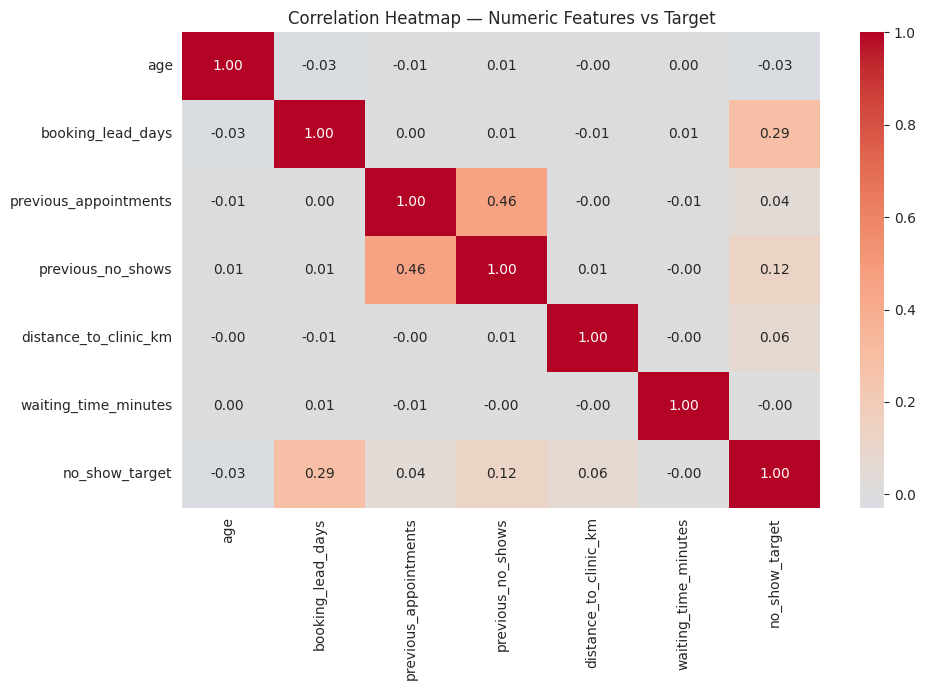

In [9]:
plt.figure(figsize=(10,7))
numeric_cols = ['age','booking_lead_days','previous_appointments','previous_no_shows',
                 'distance_to_clinic_km','waiting_time_minutes','no_show_target']
corr = model_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numeric Features vs Target")
plt.tight_layout()
plt.show()

**Correlation Heatmap — Interpretation**

booking_lead_days (0.29) is clearly the strongest numeric predictor of no_show_target, consistent with the pattern already seen in the histogram above. previous_no_shows (0.12) is a distant second, followed by distance_to_clinic_km (0.06). age (-0.03) and waiting_time_minutes (-0.00) show essentially no linear relationship with the target at all. One additional pattern worth noting: previous_appointments and previous_no_shows are moderately correlated with each other (0.46) — expected, since patients with more appointments naturally have more opportunities to have missed one, and this relationship is part of the reasoning for engineering historical_no_show_rate as a normalized alternative in Part 3. This informed prioritising booking_lead_days and previous_no_shows in the baseline model, while not expecting age, waiting_time_minutes, or distance_to_clinic_km to carry much individual weight on their own.

# Part 3: Feature Engineering

In [10]:
model_df['historical_no_show_rate'] = np.where(
    model_df['previous_appointments'] > 0,
    model_df['previous_no_shows'] / model_df['previous_appointments'],
    0
)
model_df['is_new_patient'] = (model_df['previous_appointments'] == 0).astype(int)
model_df['high_lead_time'] = (model_df['booking_lead_days'] > 14).astype(int)

print(model_df[['historical_no_show_rate','is_new_patient','high_lead_time']].describe())

       historical_no_show_rate  is_new_patient  high_lead_time
count              4737.000000     4737.000000     4737.000000
mean                  0.169127        0.048132        0.751319
std                   0.244076        0.214067        0.432294
min                   0.000000        0.000000        0.000000
25%                   0.000000        0.000000        1.000000
50%                   0.000000        0.000000        1.000000
75%                   0.333333        0.000000        1.000000
max                   1.000000        1.000000        1.000000


**Engineered Features — What, Why, Expected Value**

**historical_no_show_rate — What:** previous_no_shows divided by previous_appointments (0 for patients with no history). Why: a patient with 2 no-shows out of 2 appointments is a very different risk than one with 2 no-shows out of 20 — the rate captures that distinction the raw count can't. Expected value: a more precise behavioural risk signal.

**is_new_patient — What:** a binary flag for patients with zero appointment history. Why: new patients default to a historical_no_show_rate of 0, which could otherwise misleadingly look like "low risk" — this flag lets the model distinguish "genuinely low risk" from "unknown, no history yet." Expected value: helps the model avoid over-trusting a default value.

**high_lead_time — What:** a binary flag for bookings made more than 14 days in advance. Why: directly derived from the pattern observed in Part 2b. Expected value: an interpretable threshold version of the lead-time signal.

# Part 4: Train/Test Strategy

In [11]:
print("Total modelling rows:", len(model_df))
print("Unique patients:", model_df['patient_id'].nunique())
print("Patients with more than one appointment:", (model_df['patient_id'].value_counts() > 1).sum())

Total modelling rows: 4737
Unique patients: 1680
Patients with more than one appointment: 1337


**Why a Patient-Grouped Split**

A simple random train/test split would very likely place some of the same patient's multiple appointments into both the training and test sets. Since a patient's behavioural patterns repeat across their own appointments, this would let the model partially "see" test-set answers during training — inflating performance in a way that wouldn't hold up on genuinely new patients. A GroupShuffleSplit grouped by patient_id is used instead, guaranteeing no patient appears in both sets.

In [12]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(model_df, groups=model_df['patient_id']))
train_df = model_df.iloc[train_idx]
test_df = model_df.iloc[test_idx]

overlap = set(train_df['patient_id']) & set(test_df['patient_id'])
print("Patient overlap between train and test:", len(overlap))
print("Train size:", len(train_df), "| Test size:", len(test_df))
print("Train no-show rate:", round(train_df['no_show_target'].mean(),4))
print("Test no-show rate:", round(test_df['no_show_target'].mean(),4))

Patient overlap between train and test: 0
Train size: 3771 | Test size: 966
Train no-show rate: 0.5145
Test no-show rate: 0.5


**Split Confirmation**

Patient overlap between train and test: 0, confirming the split is fully leakage-safe — no patient's appointments appear in both sets. The split produced 3,771 training rows and 966 test rows (roughly an 80/20 split as intended). The no-show rate is nearly identical in both sets — 51.45% in training versus 50.0% in test — confirming the split is representative rather than skewed toward one outcome in either set.

# Part 5: Baseline Model

In [13]:
num_features = ['age','booking_lead_days','previous_appointments','previous_no_shows',
                 'distance_to_clinic_km','waiting_time_minutes','historical_no_show_rate',
                 'is_new_patient','high_lead_time']
cat_features = ['gender','appointment_type','appointment_day','appointment_time','reminder_sent','reminder_channel']

X_train = pd.get_dummies(train_df[num_features+cat_features], columns=cat_features, drop_first=True)
X_test = pd.get_dummies(test_df[num_features+cat_features], columns=cat_features, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df['no_show_target']
y_test = test_df['no_show_target']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training features:", X_train.shape[1])

Training features: 26


**Model Selected: Logistic Regression (with a Dummy baseline for compariso**n)

**Reason for selection:** Logistic Regression is a strong, interpretable starting point — its coefficients are directly readable, which matters for explaining findings to non-technical HealthConnect stakeholders. A DummyClassifier (predicting the majority class every time) is trained alongside it purely as a floor — any real model needs to clearly beat this to be worth reporting.

In [14]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
dummy_preds = dummy.predict(X_test_scaled)
print("Dummy baseline accuracy:", round(accuracy_score(y_test, dummy_preds), 4))

Dummy baseline accuracy: 0.5


In [15]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
preds = logreg.predict(X_test_scaled)
probs = logreg.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression trained.")

Logistic Regression trained.


# Part 6: Initial Evaluation

In [16]:
print("Accuracy: ", round(accuracy_score(y_test, preds), 4))
print("Precision:", round(precision_score(y_test, preds), 4))
print("Recall:   ", round(recall_score(y_test, preds), 4))
print("F1-score: ", round(f1_score(y_test, preds), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, probs), 4))

Accuracy:  0.6242
Precision: 0.6172
Recall:    0.6542
F1-score:  0.6352
ROC-AUC:   0.6767


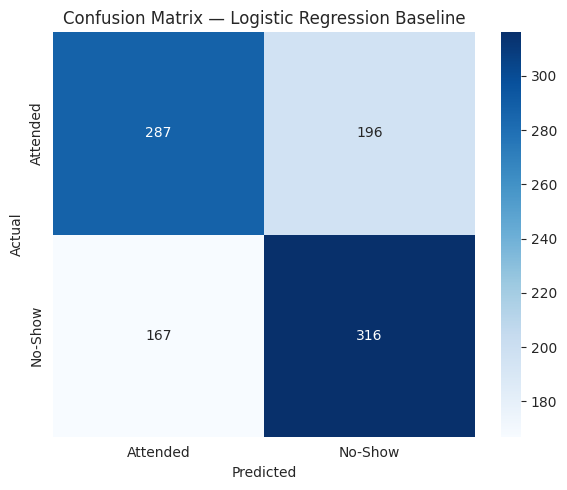

In [17]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attended','No-Show'], yticklabels=['Attended','No-Show'])
plt.title("Confusion Matrix — Logistic Regression Baseline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [18]:
coefs = pd.Series(logreg.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
print("Top 10 features by coefficient magnitude:")
print(coefs.head(10))

Top 10 features by coefficient magnitude:
booking_lead_days                        0.595111
previous_no_shows                        0.482076
historical_no_show_rate                 -0.176558
distance_to_clinic_km                    0.170728
previous_appointments                   -0.160877
appointment_day_Wednesday                0.115434
appointment_day_Thursday                 0.100810
is_new_patient                          -0.094728
appointment_type_General Consultation   -0.092262
appointment_day_Sunday                   0.088741
dtype: float64


The baseline Logistic Regression model reaches 62.4% accuracy, meaningfully ahead of the 50% dummy baseline, with a ROC-AUC of 0.677 indicating genuine, moderate discriminative ability rather than random guessing. Precision (0.617) and recall (0.654) are fairly balanced, meaning the model isn't strongly biased toward over- or under-predicting no-shows.

The two strongest predictors by coefficient magnitude are booking_lead_days (+0.595) and previous_no_shows (+0.482), both positive — meaning longer lead times and more past no-shows both increase predicted no-show risk, which matches intuition and confirms the patterns already seen in the exploratory charts. distance_to_clinic_km (+0.171) also shows a positive relationship, suggesting patients further from the clinic are somewhat more likely to miss appointments.

One result does need flagging honestly rather than ignoring: historical_no_show_rate carries a negative coefficient (-0.177), despite previous_no_shows (its close relative) being strongly positive. This is a modelling consideration, not a genuine real-world finding — it most likely reflects overlap between historical_no_show_rate and previous_no_shows once both are included together in the same model (since one is essentially derived from the other), rather than a history of no-shows actually being protective. Similarly, previous_appointments shows a negative coefficient (-0.161), which could reflect a similar overlap with previous_no_shows.

**Modelling Limitations**

* This is a first baseline, not a tuned or final model.
* A ROC-AUC of 0.677 indicates moderate, not strong, discriminative ability — the model is clearly better than guessing but leaves meaningful room for improvement, likely through resolving the feature overlap noted above and testing non-linear models in Week 6.
* The historical_no_show_rate / previous_no_shows / previous_appointments overlap identified above needs resolution before the feature set is finalised.
* Model calibration and explainability have not yet been formally assessed.

**Updated Assumptions, Limitations, Risks & Dependencies**

**Resolved:** The waiting_time_minutes leakage risk flagged in Week 4 — confirmed NOT to be leakage this week (see Part 2a). This feature is now included.

**Resolved:** Repeated-patient leakage — addressed via a patient-grouped train/test split (Part 4).

**Still relevant:** Structural missingness in reminder_channel — handled this week via an explicit "No Reminder" category.

**New issue discovered:** historical_no_show_rate and previous_appointments both showed negative coefficients in the baseline model, despite their close relative previous_no_shows being strongly positive — this points to feature overlap (redundant information) between these three related variables, which needs resolving before the feature set is finalised in Week 6.

**Still relevant:** Synthetic data limitation — all findings describe patterns in this fictional dataset, not real clinical behaviour.

**New consideration:** The baseline model's ROC-AUC of 0.677 indicates only moderate discriminative ability — it is not yet strong enough to support any discussion of operational use or deployment. Further model refinement is needed first.

**Week 5 Project Summary**

1. Planned for Week 5: Prepare the dataset for modelling, engineer meaningful features, define a train/test strategy, build a baseline model, and evaluate it.

2. Actually completed: All of the above — resolved the Week 4 leakage question for waiting_time_minutes with direct evidence, cleaned the dataset (structural missingness in reminder_channel handled explicitly), produced four exploratory visualizations each tied to a specific decision, engineered three new features, built a patient-grouped train/test split with zero patient overlap confirmed, and trained and evaluated a Logistic Regression baseline against a Dummy classifier.

3. Key findings: The baseline model reached 62.4% accuracy and a 0.677 ROC-AUC, clearly ahead of the 50% dummy baseline. booking_lead_days (+0.595) and previous_no_shows (+0.482) were the two strongest predictors by coefficient magnitude, both in the expected direction.

4. Major challenges: Determining whether waiting_time_minutes was genuinely a leakage risk required actually checking its missingness pattern by appointment outcome, rather than assuming based on its name. Interpreting the unexpected negative coefficient on historical_no_show_rate also took care — rather than presenting it as a surprising finding, I recognized it as likely feature overlap with previous_no_shows and previous_appointments.

5. Important decisions and why: Cancelled appointments were excluded from the modelling target, since a cancellation is a communicated decision rather than an unexplained absence. A patient-grouped, rather than random, train/test split was used specifically to prevent the same patient's appointments from appearing in both sets. Missing reminder_channel values were filled with an explicit "No Reminder" category rather than statistically imputed, since the missingness reflects a real behavioural pattern, not a data gap.

6. Changes to Week 4 approach: The waiting_time_minutes leakage flag from Week 4 was formally resolved based on Week 5 evidence, and the feature was included in the model.


7. Remaining work: Resolve the feature overlap between historical_no_show_rate, previous_no_shows, and previous_appointments; compare the baseline against tree-based models; perform basic hyperparameter tuning; and assess model calibration.

8. Proposed focus for Week 6: Improve on the baseline through feature refinement and comparison against alternative model families, maintaining the same leakage-aware, patient-grouped evaluation approach.